In [1]:
import setup
import importlib

In [2]:
import funcoesGraficos as fg, organizar as orgn, funcoes as fn, pandas as pd
import matplotlib.pyplot as plt, numpy as np

importlib.reload(orgn)
laureados = orgn.laureados()
democracias = orgn.democracias()
populacao = fn.extrairPopulacao()
correlDemocr = fn.correlDemocrNobel(laureados, democracias, populacao)

/usr/local/python/3.12.1/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
correlDemocr.columns

Index(['index', 'pais', 'ano', 'pontos', 'premios', 'populacao',
       'premios_per_capita'],
      dtype='str')

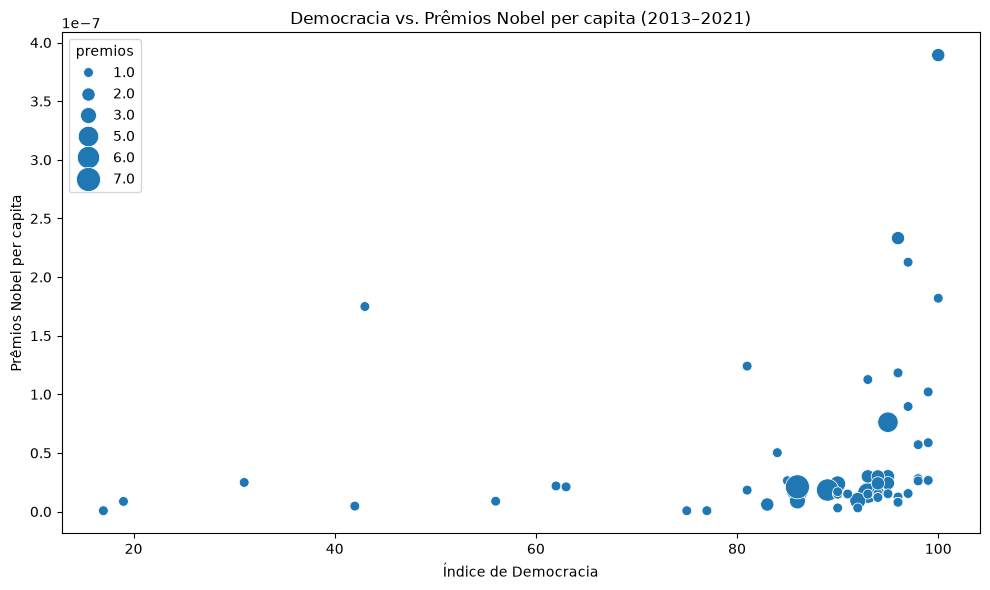

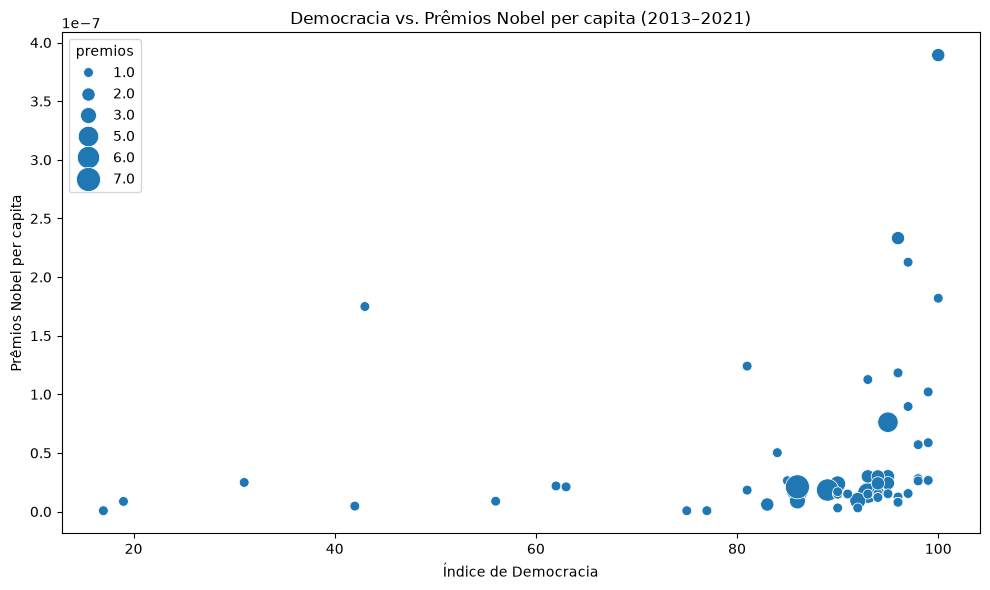

In [4]:
fg.correlDemocrNobel(correlDemocr)

In [5]:
idh = pd.read_excel("dados/dados_idh.xlsx", header=4)

idh = idh.iloc[1:201, :18].reset_index(drop=True)
idh = idh.dropna(axis=1, how='all')
idh = idh[~idh["Country"].str.contains("development", case=False, na=False)]
idh.replace("..", pd.NA, inplace=True)

idh.rename(columns={
    "Country" : "pais",
    "HDI rank" : "rank_idh"
}, inplace=True)

idh.head()

,rank_idh,pais,1990,2000,2010,2015,2020,2021,2022,2023
0,1.0,Iceland,0.841,0.902,0.935,0.956,0.965,0.967,0.964,0.972
1,2.0,Norway,0.856,0.924,0.947,0.959,0.969,0.969,0.967,0.97
2,2.0,Switzerland,0.858,0.892,0.945,0.957,0.963,0.968,0.966,0.97
3,4.0,Denmark,0.844,0.896,0.92,0.943,0.954,0.958,0.959,0.962
4,5.0,Germany,0.834,0.897,0.936,0.948,0.955,0.958,0.955,0.959


In [6]:
correlIdh = fn.correlIdhNobel(laureados, idh, populacao)
correlIdh.columns

Index(['pais', 'idh', 'premios', 'ano', 'populacao', 'premios_per_capita'], dtype='str')

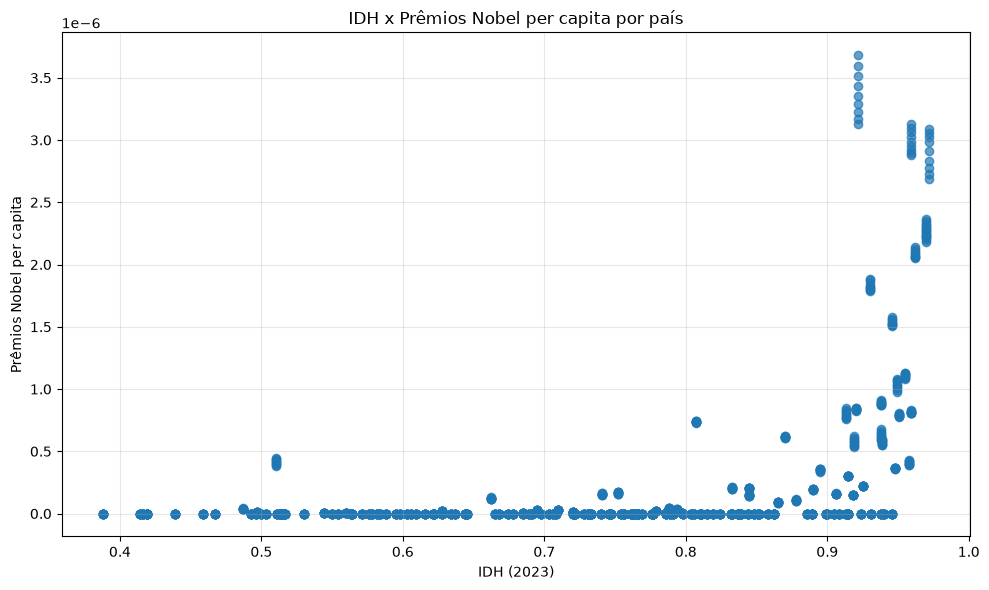

In [7]:
plt.figure(figsize=(10, 6))
df = correlIdh.copy()

plt.scatter(
    df["idh"],
    df["premios_per_capita"],
    alpha=0.7
)

plt.xlabel("IDH (2023)")
plt.ylabel("Prêmios Nobel per capita")
plt.title("IDH x Prêmios Nobel per capita por país")

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [8]:
pesq = pd.read_csv("dados/dados_P&D.csv", sep=",", skiprows=4)


pesq = pesq.drop(['Indicator Name', 'Indicator Code'], axis=1)
pesq = pesq.dropna(subset=['Country Name'])
pesq = pesq.dropna(axis=1, how='all')
pesq = pesq.rename(columns={
    'Country Name': 'pais',
    'Country Code': 'cod_pais'
})

correlPD = fn.correlPD_Nobel(laureados, pesq, populacao)

In [10]:
correlPD.columns

Index(['pais', 'pd', 'premios', 'ano', 'populacao', 'premios_per_capita'], dtype='str')

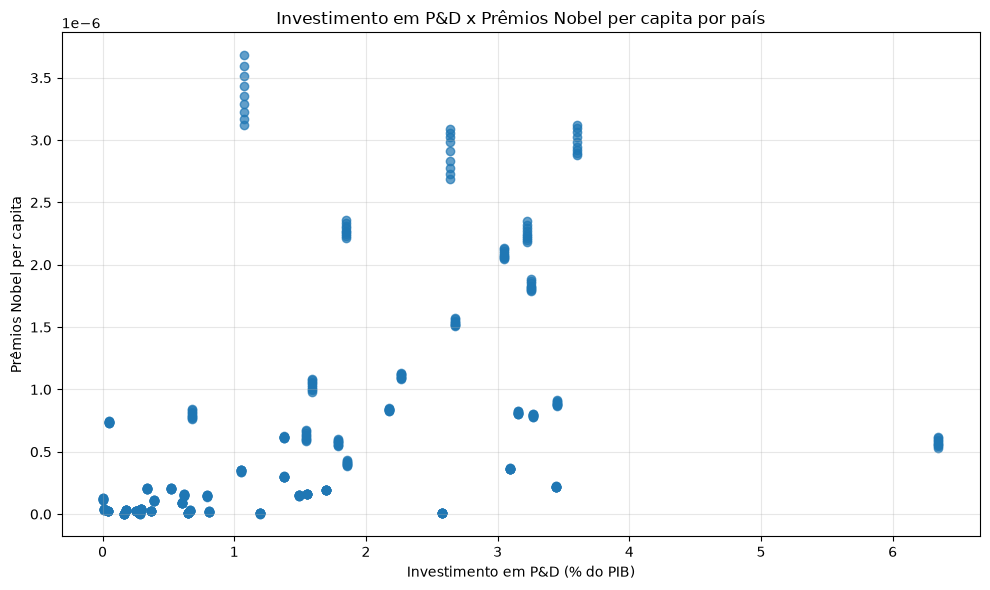

In [9]:
plt.figure(figsize=(10, 6))
df = correlPD.copy()
plt.scatter(
    df["pd"],
    df["premios_per_capita"],
    alpha=0.7
)

plt.xlabel("Investimento em P&D (% do PIB)")
plt.ylabel("Prêmios Nobel per capita")
plt.title("Investimento em P&D x Prêmios Nobel per capita por país")

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()